In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, 
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)

pd.set_option('display.float_format', '{:.4f}'.format)

# Load the clean engineered dataset
df = pd.read_csv(r"C:\Users\HP\Documents\ML Project\data\processed\application_train_clean.csv")
print(f"Shape: {df.shape}")
print(f"Target rate: {df['TARGET'].mean()*100:.2f}%")
print(f"Missing values: {df.isnull().sum().sum()}")

Shape: (307511, 102)
Target rate: 8.07%
Missing values: 0


## Baseline Model: Logistic Regression

### Why Logistic Regression first?

Every serious ML project needs a baseline — the simplest reasonable model 
that everything else gets measured against.

Logistic Regression is ideal for credit risk baseline because:
1. It is interpretable — coefficients show direction and magnitude of each feature's effect
2. It is fast — trains in seconds on 300K records
3. It is the industry standard in traditional credit scoring (scorecard models)
4. It sets a performance floor — if XGBoost doesn't beat this significantly, something is wrong

### Evaluation metrics we will use:
- **AUC-ROC**: Overall discrimination ability (threshold-independent)
- **Precision-Recall AUC**: Better for imbalanced datasets like ours
- **F1 Score**: Balance between precision and recall at default threshold
- **Confusion Matrix**: Shows actual business cost of errors

In [6]:
# Separate features and target
TARGET = 'TARGET'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features: {X.shape[1]}")
print(f"Records:  {X.shape[0]:,}")
print(f"Default rate: {y.mean()*100:.2f}%")

# Train-test split — stratified to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,          # 80% train, 20% test
    random_state=42,        # reproducible results
    stratify=y              # preserve 8.07% default rate in both splits
)

print(f"\nTrain size: {X_train.shape[0]:,} records")
print(f"Test size:  {X_test.shape[0]:,} records")
print(f"\nTrain default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate:  {y_test.mean()*100:.2f}%")

Features: 101
Records:  307,511
Default rate: 8.07%

Train size: 246,008 records
Test size:  61,503 records

Train default rate: 8.07%
Test default rate:  8.07%


In [8]:
# Logistic Regression is sensitive to feature scale
# StandardScaler brings all features to mean=0, std=1
# This prevents large-magnitude features from dominating the model

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

# Note: fit_transform on train, transform ONLY on test
# Fitting on test would cause data leakage — a common mistake

print("Scaling complete.")
print(f"Train feature mean (sample): {X_train_scaled[:, 0].mean():.4f}")
print(f"Train feature std  (sample): {X_train_scaled[:, 0].std():.4f}")

Scaling complete.
Train feature mean (sample): 0.0000
Train feature std  (sample): 1.0000


In [10]:
# class_weight='balanced' automatically adjusts weights 
# inversely proportional to class frequency
# This handles our 8.07% imbalance without SMOTE at baseline stage

lr_model = LogisticRegression(
    class_weight='balanced',    # handles class imbalance
    max_iter=1000,              # enough iterations to converge
    random_state=42,
    solver='lbfgs',             # efficient for medium-sized datasets
    C=0.1                       # mild regularisation to prevent overfitting
)

print("Training Logistic Regression...")
lr_model.fit(X_train_scaled, y_train)
print("Training complete.")

# Predict probabilities — we need probabilities, not just class labels
# for AUC-ROC calculation
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
y_pred_class = lr_model.predict(X_test_scaled)

print(f"\nSample predictions (first 10 probabilities):")
print(np.round(y_pred_proba[:10], 4))

Training Logistic Regression...
Training complete.

Sample predictions (first 10 probabilities):
[0.3827 0.3569 0.7702 0.5051 0.5996 0.6857 0.0922 0.0799 0.8549 0.4269]


AUC-ROC Score: 0.7484


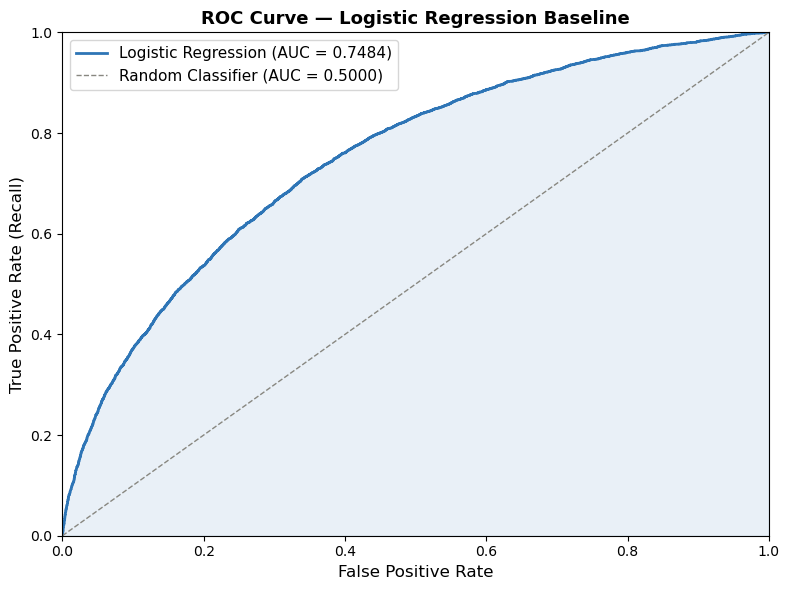


AUC-ROC: 0.7484
Interpretation: The model correctly ranks a defaulter above
a non-defaulter 74.8% of the time.


In [12]:
# Calculate AUC-ROC
auc_roc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc_roc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2E75B6', linewidth=2,
        label=f'Logistic Regression (AUC = {auc_roc:.4f})')
ax.plot([0, 1], [0, 1], color='#888780', linestyle='--', 
        linewidth=1, label='Random Classifier (AUC = 0.5000)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2E75B6')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — Logistic Regression Baseline', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(r'C:\Users\HP\Documents\ML Project\loan-default-prediction-/reports/roc_curve_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nAUC-ROC: {auc_roc:.4f}")
print(f"Interpretation: The model correctly ranks a defaulter above")
print(f"a non-defaulter {auc_roc*100:.1f}% of the time.")

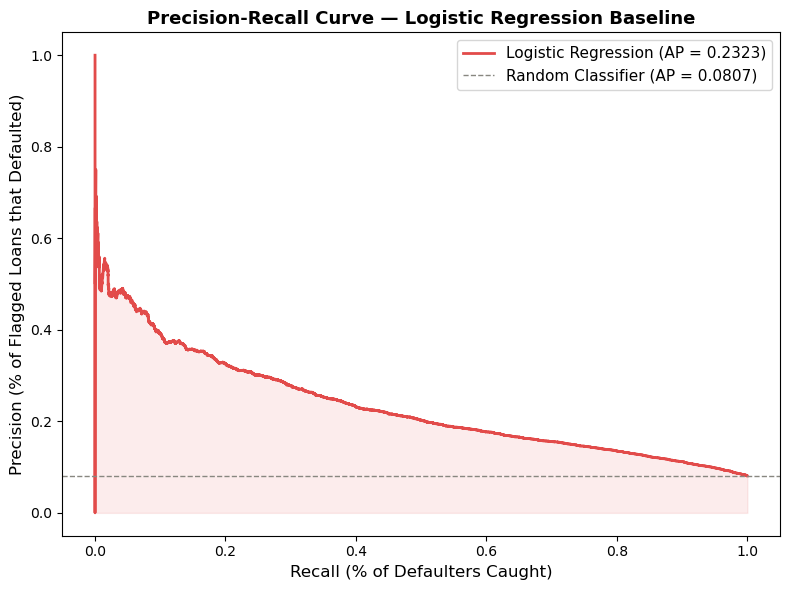

Average Precision: 0.2323


In [14]:
# Precision-Recall curve is more informative than ROC for imbalanced data
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='#E24B4A', linewidth=2,
        label=f'Logistic Regression (AP = {avg_precision:.4f})')
ax.axhline(y=y_test.mean(), color='#888780', linestyle='--',
           linewidth=1, label=f'Random Classifier (AP = {y_test.mean():.4f})')
ax.fill_between(recall, precision, alpha=0.1, color='#E24B4A')
ax.set_xlabel('Recall (% of Defaulters Caught)', fontsize=12)
ax.set_ylabel('Precision (% of Flagged Loans that Defaulted)', fontsize=12)
ax.set_title('Precision-Recall Curve — Logistic Regression Baseline',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../reports/precision_recall_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Average Precision: {avg_precision:.4f}")

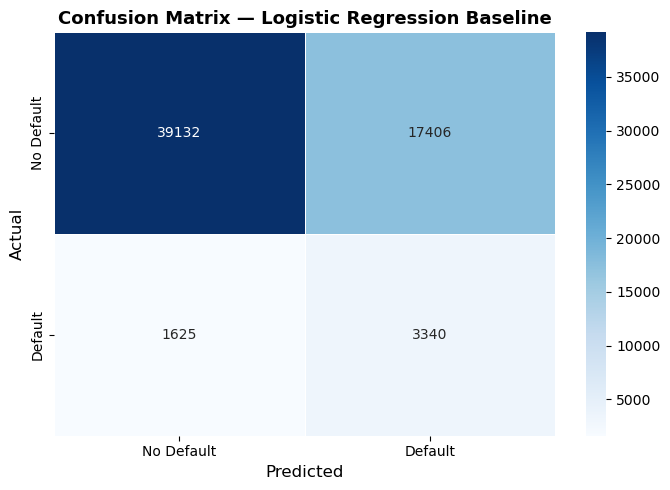


Confusion Matrix Breakdown:
True Negatives  (correctly approved): 39,132
False Positives (good borrowers rejected): 17,406
False Negatives (bad loans approved): 1,625  ← most costly
True Positives  (defaults correctly caught): 3,340

Of 4,965 actual defaults:
  Caught: 3,340 (67.3%)
  Missed: 1,625 (32.7%)


In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred_class)
cm_labels = ['No Default', 'Default']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cm_labels, yticklabels=cm_labels,
            ax=ax, linewidths=0.5)

ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_title('Confusion Matrix — Logistic Regression Baseline',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Business interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"True Negatives  (correctly approved): {tn:,}")
print(f"False Positives (good borrowers rejected): {fp:,}")
print(f"False Negatives (bad loans approved): {fn:,}  ← most costly")
print(f"True Positives  (defaults correctly caught): {tp:,}")
print(f"\nOf {fn+tp:,} actual defaults:")
print(f"  Caught: {tp:,} ({tp/(fn+tp)*100:.1f}%)")
print(f"  Missed: {fn:,} ({fn/(fn+tp)*100:.1f}%)")

In [18]:
f1 = f1_score(y_test, y_pred_class)
precision_val = precision_score(y_test, y_pred_class)
recall_val = recall_score(y_test, y_pred_class)

print("=" * 55)
print("BASELINE MODEL EVALUATION SUMMARY")
print("Logistic Regression — Home Credit Default Risk")
print("=" * 55)
print(f"\nModel:              Logistic Regression")
print(f"Training records:   {X_train.shape[0]:,}")
print(f"Test records:       {X_test.shape[0]:,}")
print(f"Features used:      {X_train.shape[1]}")
print(f"\n--- Performance Metrics ---")
print(f"AUC-ROC:            {auc_roc:.4f}")
print(f"Average Precision:  {avg_precision:.4f}")
print(f"F1 Score:           {f1:.4f}")
print(f"Precision:          {precision_val:.4f}")
print(f"Recall:             {recall_val:.4f}")
print(f"\n--- Business Interpretation ---")
print(f"The model correctly ranks a defaulter as riskier")
print(f"than a non-defaulter {auc_roc*100:.1f}% of the time.")
print(f"\nOf every 100 actual defaults in the test set:")
print(f"  {recall_val*100:.0f} are correctly flagged by the model")
print(f"  {(1-recall_val)*100:.0f} slip through undetected")
print(f"\n--- Baseline Target to Beat ---")
print(f"XGBoost must exceed AUC-ROC: {auc_roc:.4f}")
print(f"XGBoost must exceed F1:      {f1:.4f}")
print("=" * 55)

BASELINE MODEL EVALUATION SUMMARY
Logistic Regression — Home Credit Default Risk

Model:              Logistic Regression
Training records:   246,008
Test records:       61,503
Features used:      101

--- Performance Metrics ---
AUC-ROC:            0.7484
Average Precision:  0.2323
F1 Score:           0.2598
Precision:          0.1610
Recall:             0.6727

--- Business Interpretation ---
The model correctly ranks a defaulter as riskier
than a non-defaulter 74.8% of the time.

Of every 100 actual defaults in the test set:
  67 are correctly flagged by the model
  33 slip through undetected

--- Baseline Target to Beat ---
XGBoost must exceed AUC-ROC: 0.7484
XGBoost must exceed F1:      0.2598


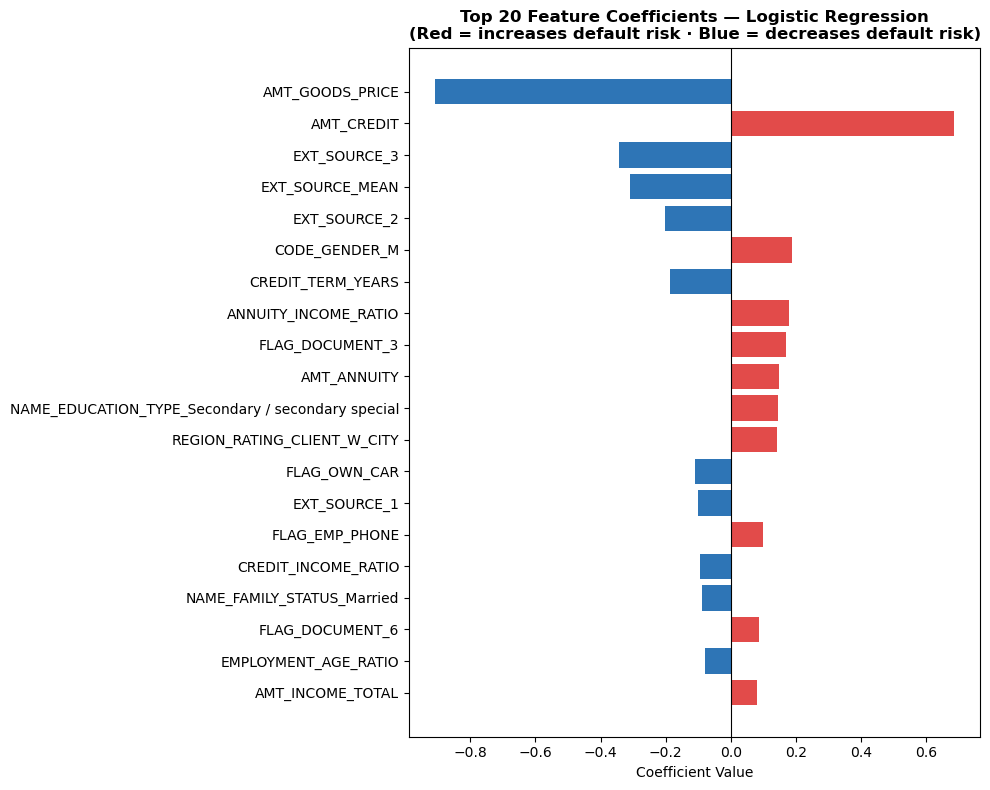


Top 10 features increasing default risk (positive coefficients):
                                              feature  coefficient
6                                          AMT_CREDIT       0.6851
73                                      CODE_GENDER_M       0.1874
67                               ANNUITY_INCOME_RATIO       0.1799
39                                    FLAG_DOCUMENT_3       0.1678
7                                         AMT_ANNUITY       0.1481
84  NAME_EDUCATION_TYPE_Secondary / secondary special       0.1454
22                        REGION_RATING_CLIENT_W_CITY       0.1413
15                                     FLAG_EMP_PHONE       0.0978
42                                    FLAG_DOCUMENT_6       0.0872
5                                    AMT_INCOME_TOTAL       0.0797

Top 10 features decreasing default risk (negative coefficients):
                       feature  coefficient
8              AMT_GOODS_PRICE      -0.9077
32                EXT_SOURCE_3      -0.3422

In [20]:
# Logistic Regression coefficients show feature importance
feature_names = X.columns.tolist()
coefficients = lr_model.coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E24B4A' if c > 0 else '#2E75B6' 
          for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], 
        color=colors, edgecolor='none')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Top 20 Feature Coefficients — Logistic Regression\n'
             '(Red = increases default risk · Blue = decreases default risk)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/feature_importance_baseline.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features increasing default risk (positive coefficients):")
print(coef_df[coef_df['coefficient'] > 0][['feature','coefficient']].head(10).to_string())
print("\nTop 10 features decreasing default risk (negative coefficients):")
print(coef_df[coef_df['coefficient'] < 0][['feature','coefficient']].head(10).to_string())